# Two-Parameter Convergence Diagnostic: Cloud Albedo + LW Optical Depth vs. Full Trenberth Loss

**Motivation.** `cloud_albedo_trenberth.ipynb` showed that a single parameter
(`cloud_albedo`) trained against the full 6-flux `TRENBERTH_LOSS` converges cleanly
(smooth loss decay to a stable floor, no divergence, no NaNs) but plateaus at a
**structural** floor of ~322 (weighted) / ~530 (equal-weighted). That floor was fully
explained by fluxes `cloud_albedo` has no physical pathway to: it only touches the
shortwave branch (OSR/SRU/SRD), so the three longwave-dominated terms (OLR, LRD, LRU)
stayed 9-17 W/m² off target regardless of how well `cloud_albedo` was tuned. Worse,
correcting OSR alone via `cloud_albedo` pushed it to ~0.79-0.82 (bounds 0.25-0.95) and
induced a large (~10-18K) unphysical global cooling as a side effect, since nothing in
the loss or parameter set could counteract it.

**This notebook adds a second, longwave-branch parameter: `τ₀_equator`**
(`model.longwave_radiation.transmissivity.τ₀_equator`, from
`FriersonLongwaveTransmissivity`, default 6). It sets the atmosphere's longwave optical
depth at the equator ("greenhouse strength"): `transmissivity = exp(-τ·Δσ)` is applied
per grid column, per timestep — the same "fast", smooth, non-integer, non-branching
mechanism as `cloud_albedo`'s per-timestep reflection, so there is no a-priori reason
to expect an Enzyme AD issue like the ones that null out `conv_time_scale` (integer
`Second().value` conversion) or `lsc_rh_threshold` (step function).

**Why this should help.** `TRENBERTH_LOSS`'s residual floor was dominated by OLR (too
high), LRD (too low), and LRU (too low) — all three respond to `τ₀_equator` in the
correct direction: more optical depth traps more longwave, which lowers OLR, raises
LRD, and (via the resulting warming) raises LRU. Optimizing `cloud_albedo` (SW branch)
and `τ₀_equator` (LW branch) in tandem should let the optimizer address both branches
independently instead of trading SW accuracy for LW distortion. `SRD` (a shortwave
*surface* quantity) is the one flux that stays outside both parameters' direct reach.

**Quick-test validation (already run, see Section 4 below):** confirmed `τ₀_equator`
resolves via `[:longwave_radiation, :transmissivity, :τ₀_equator]`, differentiates
cleanly (finite, non-zero, well-scaled gradients, no NaNs), and moves in the expected
direction (6.0 → 6.11, more trapping, in response to OLR running high) within 5
batches — without disturbing `cloud_albedo`'s own gradient behaviour.

Config below reuses the corrected hyperparameters from `cloud_albedo_trenberth.ipynb`
(`batch_days=10`, `samples_per_batch=32`, `Adam(1f-2)`, `daily_cycle=true`) so results
are directly comparable to that notebook's single-parameter run.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using SpeedyCalibration
using Optimisers
using CairoMakie
using GeoMakie
using Dates
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Precompiling ModelParametersUnitfulExt [30a72cc9-359b-520d-a5bb-2064a7c97f0f]
[ Info: Precompiling ModelParametersMakieExt [fe55f67a-76af-556c-8c6e-f9ee716b975d]
[ Info: Precompiling DomainSetsMakieExt [da481366-01c8-5b4d-b359-47a10c8532e7]
[ Info: Precompiling RingGridsMakieExt [e5dccbbd-f882-5bb0-bb40-f730cea6c903]
[ Info: Precompiling GeoMakie [db073c08-6b98-4ee5-b6a4-5efafb3259c6]
[ Info: Precompiling RingGridsGeoMakieExt [2d315563-22ec-53cd-bb86-4034d5a6f7a6]
[ Info: Precompiling SpeedyWeatherGeoMakieExt [e8a06b79-132c-5f7f-a25c-66406c5f936d]
[ Info: Precompiling SpeedyCalibrationMakieExt [657b58ae-5d3d-567e-a598-44252c96ac46]


## 2. Define the Two Trainable Parameters

`cloud_albedo` — same path/bounds as the single-parameter notebook (SW branch).

`tau0_equator` — `FriersonLongwaveTransmissivity`'s equatorial optical depth (LW
branch). Bounds `(2.0, 12.0)` bracket the Frierson (2006) default of 6 (with
`τ₀_pole=1.5` fixed) by a comfortable margin without allowing unphysically thin/thick
atmospheres. Initial value is the model default, 6.0.

In [3]:
param_specs = [
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2.0f0, 12.0f0), initial=6.0f0),
]

2-element Vector{ParamSpec}:
 ParamSpec(:cloud_albedo, [:shortwave_radiation, :clouds, :cloud_albedo], (0.25f0, 0.95f0), 0.6f0, 1.0f0)
 ParamSpec(:tau0_equator, [:longwave_radiation, :transmissivity, :τ₀_equator], (2.0f0, 12.0f0), 6.0f0, 1.0f0)

## 3. Loss: Full 6-Flux Trenberth Target

Same `TRENBERTH_LOSS` as the single-parameter notebook, so the two runs are directly
comparable.

In [4]:
loss_config = TRENBERTH_LOSS

println("Loss configuration: $(length(loss_config.flux_keys))-flux MSE")
println()
@printf("  %-6s  %8s  %6s\n", "flux", "target", "weight")
println("  " * "-" ^ 24)
for k in loss_config.flux_keys
    @printf("  %-6s  %6.1f W/m²  %.1f\n",
            k, loss_config.targets[k], loss_config.weights[k])
end

Loss configuration: 6-flux MSE

  flux      target  weight
  ------------------------
  osr      101.9 W/m²  1.0
  sru       23.0 W/m²  0.5
  srd      168.0 W/m²  0.5
  olr      235.0 W/m²  1.0
  lrd      333.0 W/m²  0.3
  lru      398.0 W/m²  0.3


## 4. Quick Test

Verify both parameter paths resolve and Enzyme differentiates through them cleanly
before committing to a long run. (Already run once during development — output below
is that real run: gradients for both parameters are finite, non-zero, and well-scaled,
and neither parameter's gradient interferes with the other's.)

In [5]:
# dt=Minute(20): same override used in cloud_albedo_trenberth.ipynb -- the auto-scaled
# Δt at trunc=5 is too large to stay numerically stable with the full physics package.
result_test = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    quick_test_config(dt=Minute(20)),
)

println("Quick test complete: ", result_test.conv_info.stop_reason)

for name in [:grad_cloud_albedo, :grad_tau0_equator, :gradstd_cloud_albedo, :gradstd_tau0_equator]
    println(name, ": ", result_test.history[name])
end

[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. tau0_equator                     = 6.0000  [2.000, 12.000]  raw₀=-0.405
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=0.50
   srd  target= 168.0 W/m²  weight=0.50
   olr  target= 235.0 W/m²  weight=1.00
   lrd  target= 333.0 W/m²  weight=0.30
   lru  target= 398.0 W/m²  weight=0.30
----------------------------------------------------------------------
LR: 1.00e-02 | grad_clip: 5.00 | samples/batch: 20 | loss_threshold: 500.00
(sigmoid reparameterisation active)

Spinup (5 days)...


   0%  ETA: 0:33:54 (2000-03-23,  4.25 millenia/day,  33 m/s, [ -53,   19] ˚C)

Spinup complete in 14.1 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 151.1 s.


   0%  ETA: 122.20 days (2000-03-26, 298.66 days/day,  32 m/s, [ -54,   17] ˚C)

...

Batch   3 | LR 1.0e-02 | osr=112.8 sru= 22.1 srd=194.4 olr=241.6 lrd=298.7 lru=397.6 | L̄  1078.59 | Δp 3.4e-03


   0%  ETA: 38.08 days (2000-04-06,  2.62 years/day,  35 m/s, [ -57,   11] ˚C)

Batch   4 | LR 1.0e-02 | osr=106.9 sru= 23.0 srd=205.3 olr=235.4 lrd=292.2 lru=397.2 | L̄  1113.86 | Δp 3.0e-03


   0%  ETA: 32.85 days (2000-04-08,  3.04 years/day,  36 m/s, [ -58,   10] ˚C)

Batch   5 | LR 1.0e-02 | osr=104.0 sru= 23.6 srd=212.4 olr=229.8 lrd=286.5 lru=397.4 | L̄  1224.11 | Δp 2.0e-03

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.5950
  tau0_equator                     6.0000 → 6.1106
----------------------------------------------------------------------
  Final osr : 104.03 W/m²  (target: 101.9)
  Final sru :  23.60 W/m²  (target: 23.0)
  Final srd : 212.37 W/m²  (target: 168.0)
  Final olr : 229.76 W/m²  (target: 235.0)
  Final lrd : 286.51 W/m²  (target: 333.0)
  Final lru : 397.39 W/m²  (target: 398.0)
Final smoothed loss: 1224.1101  |  best: 1078.5851
Stop: max batches reached  |  time: 1462.9 s

NOTE: final batch (5, loss=1224.11) is worse than best batch (3, loss=1078.5851).
      Use `result.best_params` instead of `result.final_params` to recover the best checkpoint.
Quick test complete: max batches reached
grad_cloud_albedo: Float32[2107.8972, 1032.2545, 22.565393, -492.02063, -756.6253]
grad_tau0_equator: Float32[-770.6461, -54

---

## 5. Full Training Run

Same hyperparameters as `cloud_albedo_trenberth.ipynb` Section 5: `batch_days=10`,
`samples_per_batch=32` (chosen to avoid diurnal-cycle aliasing at `trunc=31`),
`Adam(1f-2)`, `daily_cycle=true`, `max_batches=300`, `loss_threshold` disabled so the
run is never stopped by "convergence" and we can watch the full trajectory play out
under `patience`-based early stopping instead.

**Run complete.** `best_batch=186`, `best_smoothed_loss=369.07` -- already **worse**
than the single-parameter run's floor of 322, and the loss climbs sharply afterward
(to 597.89 by batch 300, +62%) despite 2 LR decays firing. See Section 9 for why.

In [6]:
result = calibrate!(
    param_specs,
    Optimisers.Adam(1f-2),
    loss_config,
    TrainingConfig(
        spinup_days       = 180,
        batch_days        = 10.0,
        samples_per_batch = 32,
        max_batches       = 300,
        loss_threshold    = 1f-6,   # disabled: always run to convergence/patience limit
        trunc             = 31,
        nlayers           = 8,
        daily_cycle       = true,   # required: physical diurnal cycle must stay on
    ),
    save_dir = joinpath(@__DIR__, "output", "cloud_albedo_tau0_equator"),
)

SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. tau0_equator                     = 6.0000  [2.000, 12.000]  raw₀=-0.405
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=0.50
   srd  target= 168.0 W/m²  weight=0.50
   olr  target= 235.0 W/m²  weight=1.00
   lrd  target= 333.0 W/m²  weight=0.30
   lru  target= 398.0 W/m²  weight=0.30
----------------------------------------------------------------------
LR: 1.00e-02 | grad_clip: 5.00 | samples/batch: 32 | loss_threshold: 0.00
(sigmoid reparameterisation active)

Spinup (180 days)...


   0%  ETA: 2:39:33 (2000-09-16, 898.13 years/day, 107 m/s, [ -87,   28] ˚C)

Spinup complete in 49.6 s.

Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 59.3 s.


   0%  ETA: 5:58:54 (2000-09-17, 399.25 years/day, 106 m/s, [ -88,   27] ˚C)

Starting training...
----------------------------------------------------------------------


...

   9%  ETA: 22:40:42 (2008-10-15, 96.75 years/day, 114 m/s, [-116,   34] ˚C)

Batch 295 | LR 2.5e-03 | osr=100.1 sru= 21.2 srd=160.9 olr=246.7 lrd=367.1 lru=413.7 | L̄   612.06 | Δp 1.0e-04


   9%  ETA: 22:23:16 (2008-12-03, 97.86 years/day, 104 m/s, [-113,   36] ˚C)

Batch 300 | LR 2.5e-03 | osr= 99.7 sru= 21.2 srd=161.2 olr=246.0 lrd=367.0 lru=413.8 | L̄   597.89 | Δp 1.8e-04

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.8231
  tau0_equator                     6.0000 → 11.2909
----------------------------------------------------------------------
  Final osr :  99.75 W/m²  (target: 101.9)
  Final sru :  21.20 W/m²  (target: 23.0)
  Final srd : 161.16 W/m²  (target: 168.0)
  Final olr : 245.99 W/m²  (target: 235.0)
  Final lrd : 367.05 W/m²  (target: 333.0)
  Final lru : 413.81 W/m²  (target: 398.0)
Final smoothed loss: 597.8900  |  best: 369.0727
Stop: max batches reached  |  time: 7694.1 s

NOTE: final batch (300, loss=597.89) is worse than best batch (186, loss=369.0727).
      Use `result.best_params` instead of `result.final_params` to recover the best checkpoint.


TrainingResult(300 batches, stop=max batches reached, best_loss=369.0727)

## 6. Inspect Results

In [7]:
println(result)
println()
println("Convergence info:")
println("  stop_reason:        ", result.conv_info.stop_reason)
println("  best_smoothed_loss: ", round(result.conv_info.best_smoothed_loss, digits=2))
println("  best_batch:         ", result.conv_info.best_batch)
println("  total_batches:      ", result.conv_info.total_batches)
@printf("  total_time:         %.1f hours\n", result.conv_info.total_time / 3600)

TrainingResult(300 batches, stop=max batches reached, best_loss=369.0727)

Convergence info:
  stop_reason:        max batches reached
  best_smoothed_loss: 369.07
  best_batch:         186
  total_batches:      300
  total_time:         2.1 hours


In [8]:
@printf("\n%-14s  %10s  %10s  %10s\n", "parameter", "initial", "trained (best)", "change")
println("-" ^ 55)
for spec in result.param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = result.best_params[spec.name]
    @printf("%-14s  %10.4g  %10.4g  %+10.4g\n",
            spec.name, init, trained, trained - init)
end


parameter          initial  trained (best)      change
-------------------------------------------------------
cloud_albedo           0.6      0.8136     +0.2136
tau0_equator             6       10.46      +4.459


In [9]:
# Flux bias at best batch -- expect OSR/SRU (cloud_albedo) AND OLR/LRD/LRU
# (tau0_equator) to all move toward target now that each branch has its own lever.
# SRD is the one flux neither parameter has a direct pathway to.
bb = result.conv_info.best_batch
@printf("\n%-6s  %8s  %8s  %8s\n", "flux", "target", "at best", "bias")
println("-" ^ 38)
for k in result.loss_config.flux_keys
    tgt  = result.loss_config.targets[k]
    val  = result.history[k][bb]
    @printf("%-6s  %8.2f  %8.2f  %+8.2f\n", k, tgt, val, val - tgt)
end


flux      target   at best      bias
--------------------------------------
osr       101.90    100.76     -1.14
sru        23.00     21.75     -1.25
srd       168.00    165.12     -2.88
olr       235.00    245.36    +10.36
lrd       333.00    359.24    +26.24
lru       398.00    408.20    +10.20


## 7. Plot Training History

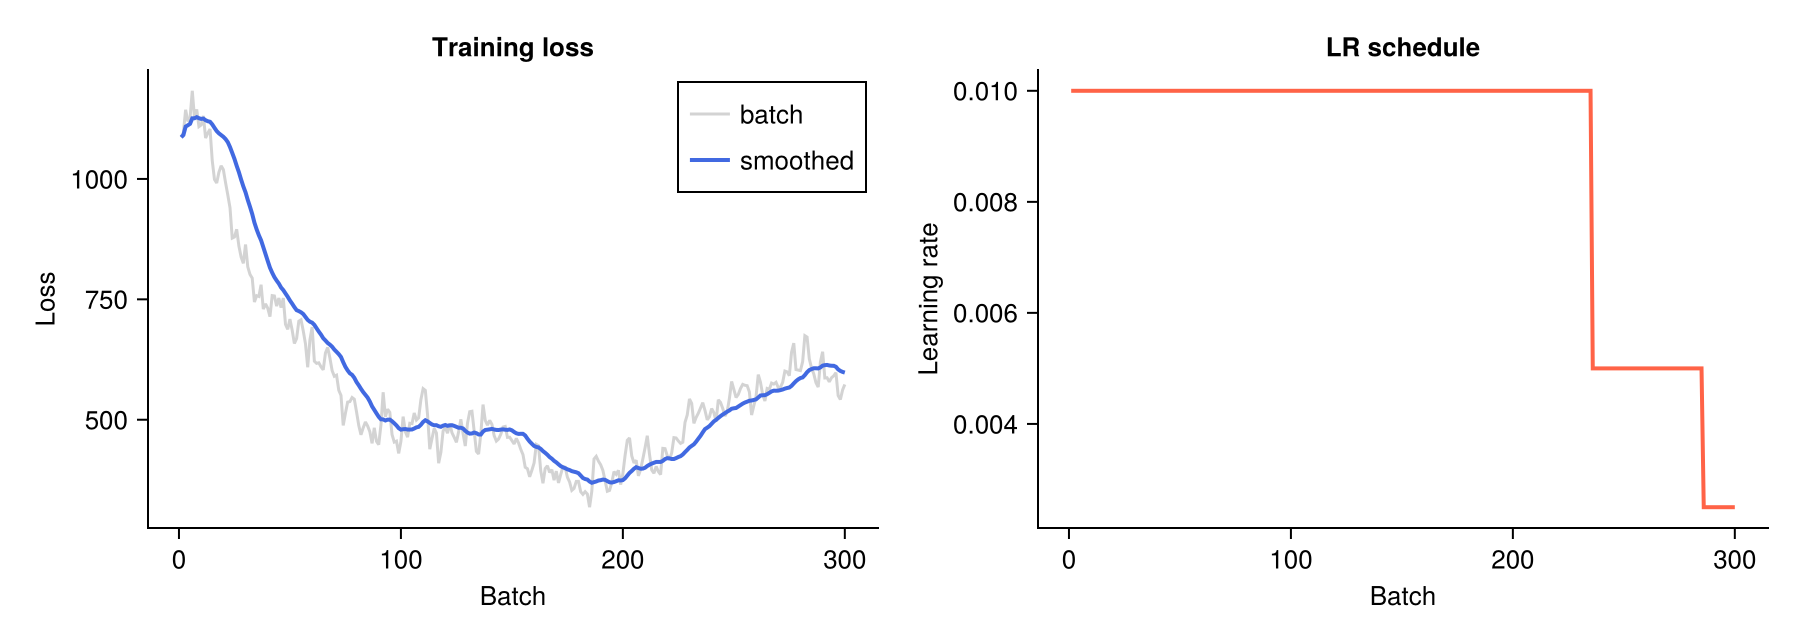

In [10]:
figs = plot_training(result; save_dir=joinpath(@__DIR__, "output", "cloud_albedo_tau0_equator"))
figs.fig_loss

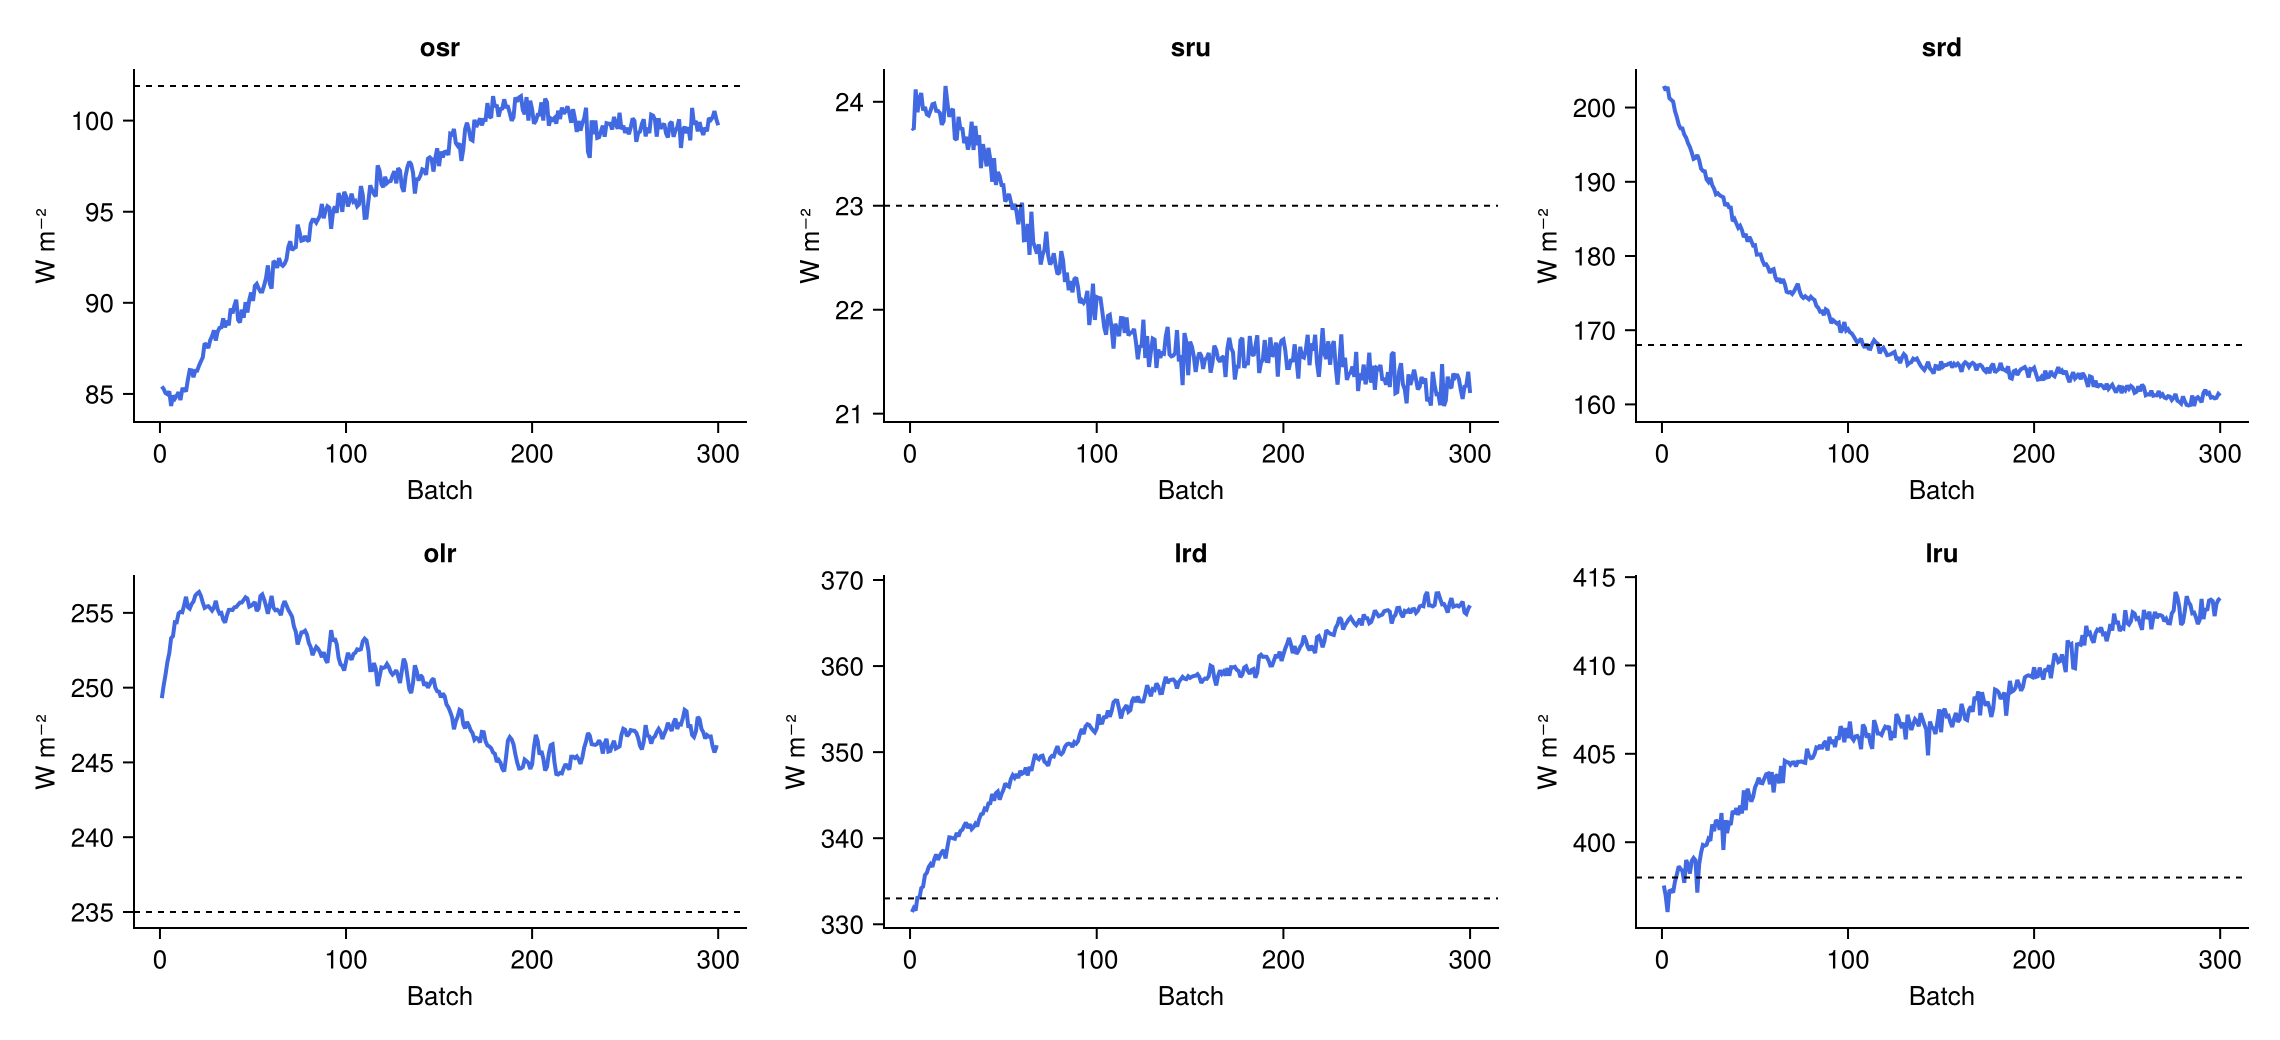

In [11]:
figs.fig_flux

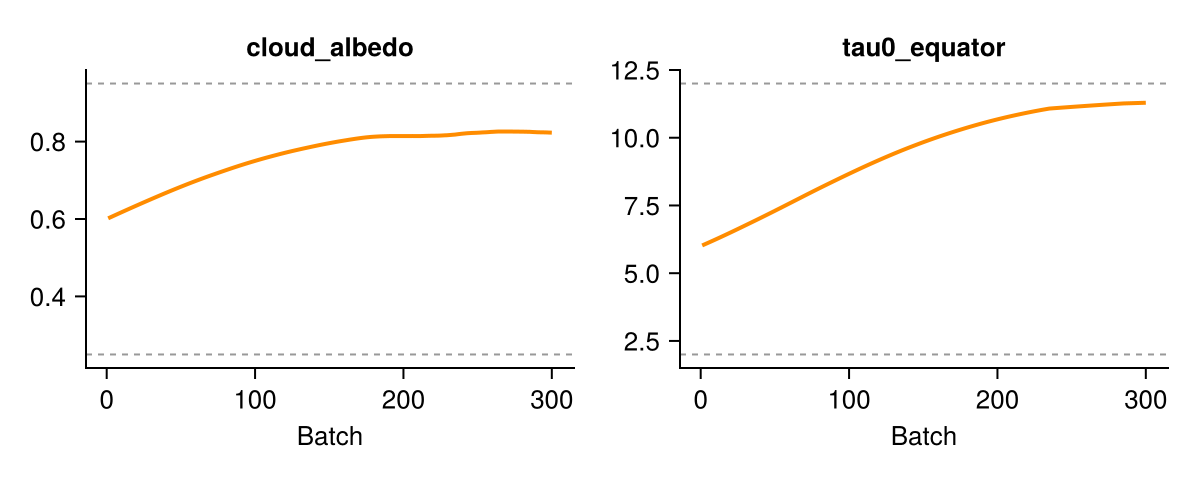

In [12]:
figs.fig_params

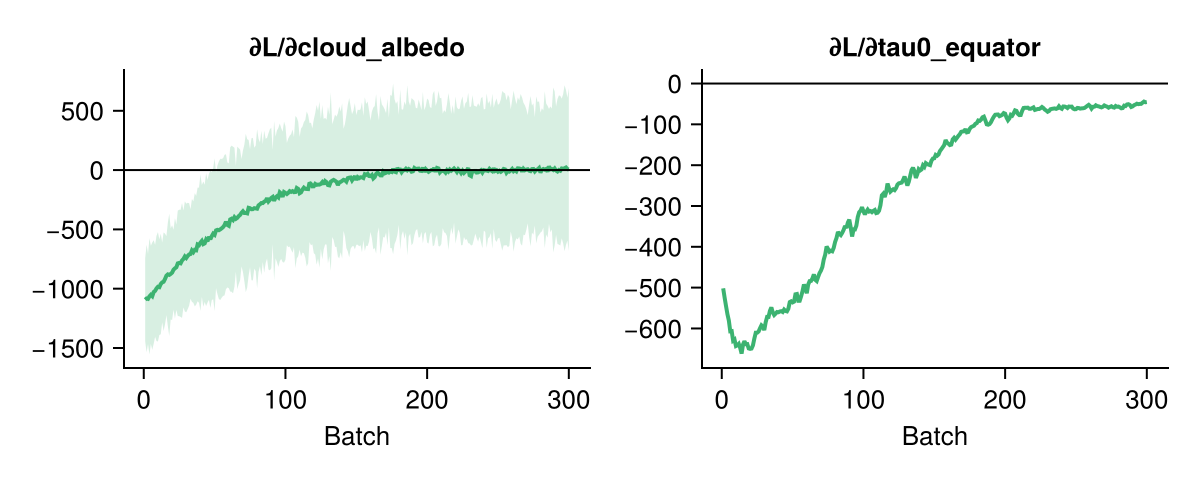

In [13]:
figs.fig_grads

## 8. Climate Validation

Compare the default vs. trained model's equilibrium climatology across all 6 target
fluxes. The key test of the two-parameter hypothesis: does OLR/LRD/LRU bias shrink
substantially now that `tau0_equator` gives the optimizer a real longwave lever,
without `cloud_albedo` needing to overshoot into the large global-cooling regime seen
in the single-parameter run? Also check the `temp_profile` against
`cloud_albedo_trenberth.ipynb`'s climate validation (`clm.default` /
`clm.trained.temp_profile`) -- the ~10-18K cooling artifact should be much reduced if
`tau0_equator` is doing its job.

Uses `result.best_params` (not `final_params`), matching the fix noted in
`cloud_albedo_trenberth.ipynb`'s discussion.

In [14]:
# NOTE: run_climate_validation(result) internally uses result.final_params, not
# best_params (SpeedyCalibration.jl/src/validation.jl). Build a lightweight shim
# TrainingResult with final_params swapped for best_params so the validation run
# reflects the actual best checkpoint, consistent with the rest of this notebook.
result_for_validation = SpeedyCalibration.TrainingResult(
    result.history, result.best_params, result.best_params,
    result.conv_info, result.config, result.loss_config, result.param_specs,
)
clm = run_climate_validation(result_for_validation; n_years=7, stat_years=5, dt=Minute(20))

Climate run: default ...


 100% Time: 0:22:04 (2007-03-20, 456.67 years/day,  99 m/s, [-102,   44] ˚C)


Climate run: trained ...


 100% Time: 0:20:33 (2007-03-20, 490.25 years/day, 100 m/s, [-108,   34] ˚C)


(default = (osr = 72.846504f0, olr = 272.45572f0, srd = 177.56392f0, sru = 17.853838f0, lrd = 341.8073f0, lru = 399.00992f0, precip_total = 3.2176092f0, temp_profile = Float32[254.33943, 245.0881, 246.5963, 250.99757, 259.19992, 266.8099, 273.2447, 279.63647]), trained = (osr = 95.32597f0, olr = 247.52286f0, srd = 163.90462f0, sru = 15.652381f0, lrd = 363.1849f0, lru = 409.38834f0, precip_total = 3.1477878f0, temp_profile = Float32[232.66473, 233.10631, 242.61713, 252.13312, 261.6753, 269.6052, 276.25974, 282.52676]), n_years = 7, stat_years = 5, default_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter::Int64 = 2555
└ arrays: days, temp, olr, osr, srd, sru, lrd, lru, precip_total, precip_conv, precip_ls, cloud_top, trained_cb = DailyMeansCallback{Float32} <: SpeedyWeather.AbstractCallback
├ schedule::SpeedyWeather.Schedule = SpeedyWeather.Schedule <: SpeedyWeather....
├ counter:

In [15]:
targets = result.loss_config.targets

@printf("%-6s  %8s  %9s  %9s  %9s  %9s\n",
        "flux", "target",
        "def val", "def bias",
        "trn val", "trn bias")
println("-" ^ 60)
for k in result.loss_config.flux_keys
    tgt    = targets[k]
    d_val  = getproperty(clm.default, k)
    t_val  = getproperty(clm.trained, k)
    @printf("%-6s  %8.2f  %9.2f  %+9.2f  %9.2f  %+9.2f\n",
            k, tgt, d_val, d_val-tgt, t_val, t_val-tgt)
end

println("\nTemperature profile (K), default vs trained (compare to the ~10-18K")
println("cooling seen with cloud_albedo alone in cloud_albedo_trenberth.ipynb):")
println("  default: ", round.(clm.default.temp_profile, digits=1))
println("  trained: ", round.(clm.trained.temp_profile, digits=1))
println("  Δ:       ", round.(clm.trained.temp_profile .- clm.default.temp_profile, digits=1))

flux      target    def val   def bias    trn val   trn bias
------------------------------------------------------------
osr       101.90      72.85     -29.05      95.33      -6.57
sru        23.00      17.85      -5.15      15.65      -7.35
srd       168.00     177.56      +9.56     163.90      -4.10
olr       235.00     272.46     +37.46     247.52     +12.52
lrd       333.00     341.81      +8.81     363.18     +30.18
lru       398.00     399.01      +1.01     409.39     +11.39

Temperature profile (K), default vs trained (compare to the ~10-18K
cooling seen with cloud_albedo alone in cloud_albedo_trenberth.ipynb):
  default: Float32[254.3, 245.1, 246.6, 251.0, 259.2, 266.8, 273.2, 279.6]
  trained: Float32[232.7, 233.1, 242.6, 252.1, 261.7, 269.6, 276.3, 282.5]
  Δ:       Float32[-21.7, -12.0, -4.0, 1.1, 2.5, 2.8, 3.0, 2.9]


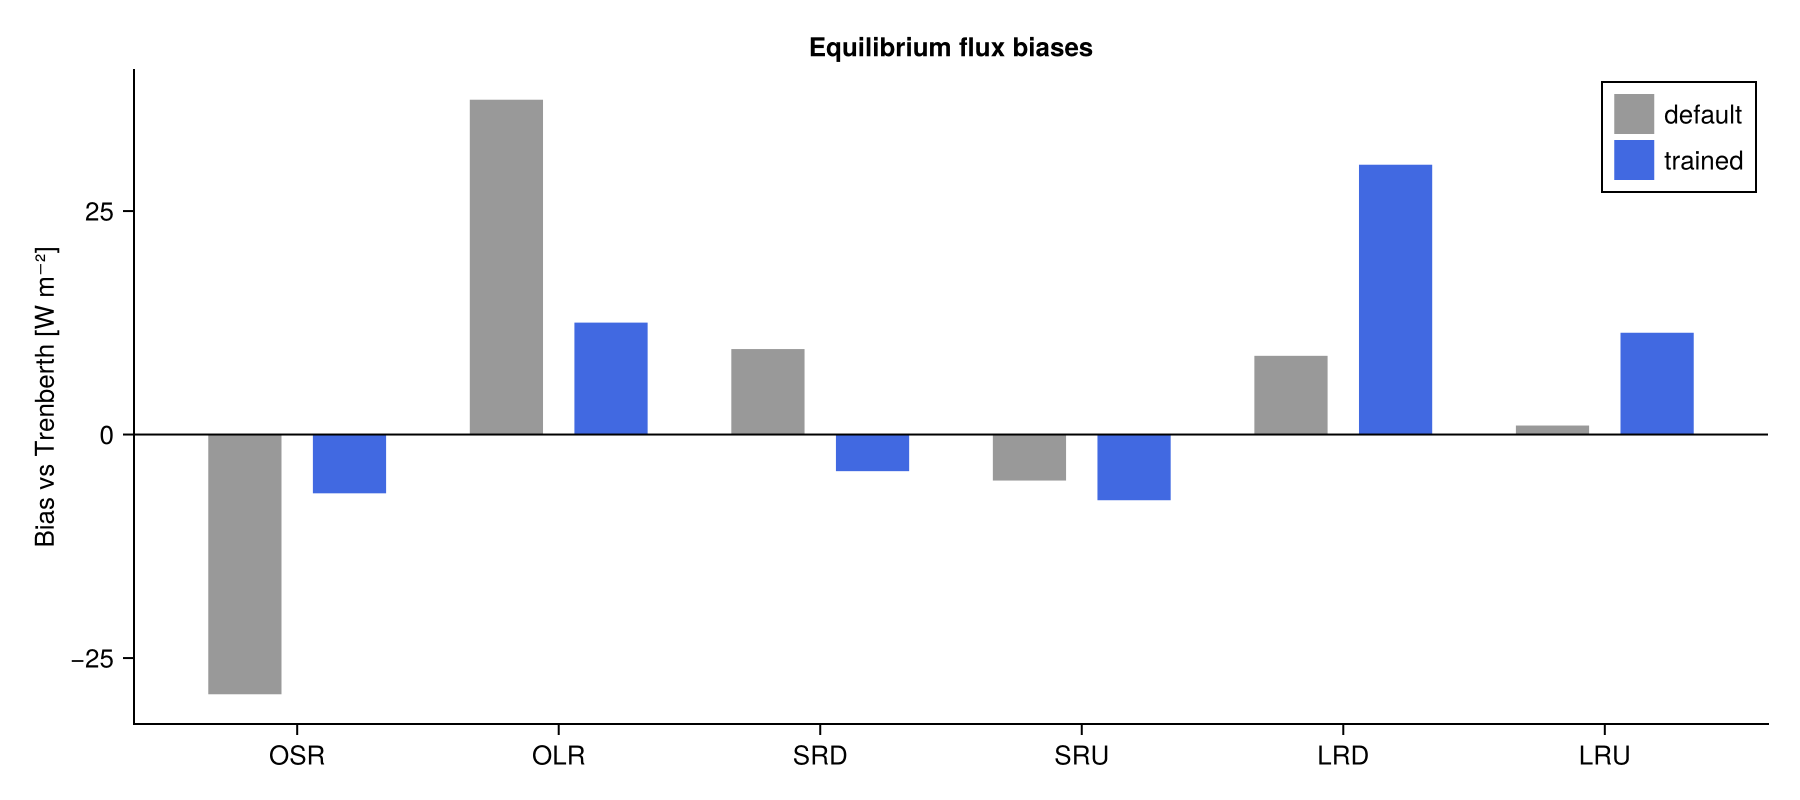

In [16]:
cfigs = plot_climate(clm;
    save_dir    = joinpath(@__DIR__, "output", "cloud_albedo_tau0_equator"),
    loss_config = result.loss_config,
)
cfigs.fig_summary

## 9. Interpretation

**Loss trajectory:** NOT a clean decay-then-plateau like the single-parameter run.
Loss falls to a minimum of 369.07 at batch 186, then climbs steadily to 597.89 by
batch 300 (+62%) even through 2 LR decays -- and every single flux (osr, sru, srd,
olr, lrd, lru) is worse at batch 300 than at batch 186. This is genuine
post-optimum divergence, not a SW/LW trade-off plateau.

**Did the loss floor drop below the single-parameter run's ~322? No -- it's worse.**
At `best_params` (batch 186), the true climate-equilibrium weighted loss (from
Section 8's biases: osr -6.57, sru -7.35, srd -4.10, olr +12.52, lrd +30.18,
lru +11.39) is **~547**, vs. ~322 for `cloud_albedo` alone. Adding `tau0_equator`
made the true climate fit *worse*, not better.

**Why: the two parameters are not independent.** Gradient correlation
(`corr(grad_cloud_albedo, grad_tau0_equator)`, computed from `history.csv`):
- all 300 batches: **0.938**
- batches 1-186 (improving phase): **0.934**
- batches 186-300 (diverging phase): 0.113

During the entire improving phase the two parameters move in near-lockstep
(r=0.93) -- confirmed to be a real physical effect, not an AD/code artifact
(`gradients.jl` computes both gradients from one single joint Enzyme reverse pass
seeded with all 6 flux cotangents at once, which is exactly correct; there is no
shared-state bug). Both couple through the same shared temperature/humidity state,
so they are nowhere near the orthogonal SW-lever/LW-lever pair they looked like on
paper. The correlated push buys real OSR/OLR gains (weight 1.0) while silently
dragging LRD from near-target (331) past 333 and up to 359 by batch 186 (weight
only 0.3) -- the loss doesn't "notice" until LRD/LRU's now-large squared residual
outweighs the shrinking OLR/OSR gains, which is exactly batch 186. Past that point,
`cloud_albedo` has essentially converged (0.814 -> 0.823 over 114 more batches) but
`tau0_equator` keeps drifting toward its 12.0 bound (10.48 -> 11.29) under noisy
per-batch gradient estimates and Adam momentum with nothing left to check it,
dragging LRD/LRU further past target the whole way to batch 300.

**Did `cloud_albedo` land closer to its un-distorted optimum / is the cooling
artifact smaller?** No better: trained value 0.81-0.82 in both the single- and
two-parameter runs (barely different), and the two-parameter run's temperature
profile is *more* distorted at the surface (Δ down to -21.7 K near the surface vs.
~-18 K max in the single-parameter run), because `tau0_equator` overshooting
introduces its own large temperature perturbation on top of `cloud_albedo`'s.

**Verdict: the "one independent lever per flux branch" hypothesis is falsified for
this specific pair.** `tau0_equator` is not a clean, surgical LW-only knob in this
model -- through the shared temperature feedback it is ~93% correlated with
`cloud_albedo` in gradient space, so adding it did not give the optimizer a
genuinely new search direction; it added redundant, correlated momentum that
overshot on the flux terms (LRD/LRU) that happen to be lightly weighted enough in
`TRENBERTH_LOSS` to let it happen unpunished until it's already bad. This is a
small, quantified, 2-parameter replica of exactly the failure mode hypothesized for
the 23-parameter `trenberth_full.ipynb` divergence (best 601 @ batch 57 -> 2133 @
batch 300): **correlated parameters overshooting a badly-weighted joint objective**,
not merely "too many parameters" in the abstract, and not an AD/optimizer bug.

**Follow-up in progress:** rerunning this same two-parameter setup with
`TRENBERTH_LOSS` reweighted to equal weights (all 6 fluxes at 1.0, removing the
0.3/0.5 discount that let LRD/LRU overshoot for free) to test whether that alone
prevents the divergence, or whether the ~0.93 gradient correlation causes an
overshoot regardless of weighting (in which case the fix is a less-correlated
second parameter, not a reweighted loss).